In [ ]:
%cd /Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code

%pwd

import numpy as np
from typing import Union, Optional, List, Any, Tuple, Callable, Dict
from itertools import product
import pandas
import matplotlib.pyplot as plt

from scipy.sparse.linalg import cg
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import lil_matrix, csr_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.datasets import fetch_openml


import landmark
import voltagemap
import problem
import solver
import visualization
import setofpoints
import kmeans
from Utilities import config



workspace_file="config.params['save_data']"
!ls -l $workspace_file
import dill
with open(workspace_file, "rb") as f:
    workspace_data = dill.load(f)

voltages_so_far=workspace_data["all_voltages"].all_solutions()
voltages_so_far.shape



/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code
-rw-r--r--@ 1 yoavfreund  staff  11298072 Jul 10 10:54 config.params['save_data']


(1000, 1000)

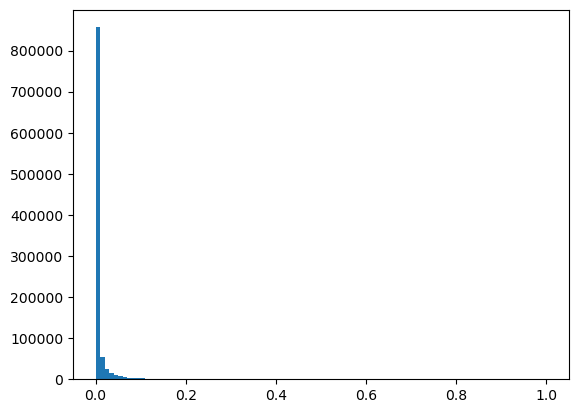

In [8]:
plt.hist(voltages_so_far.flatten(), bins=100);


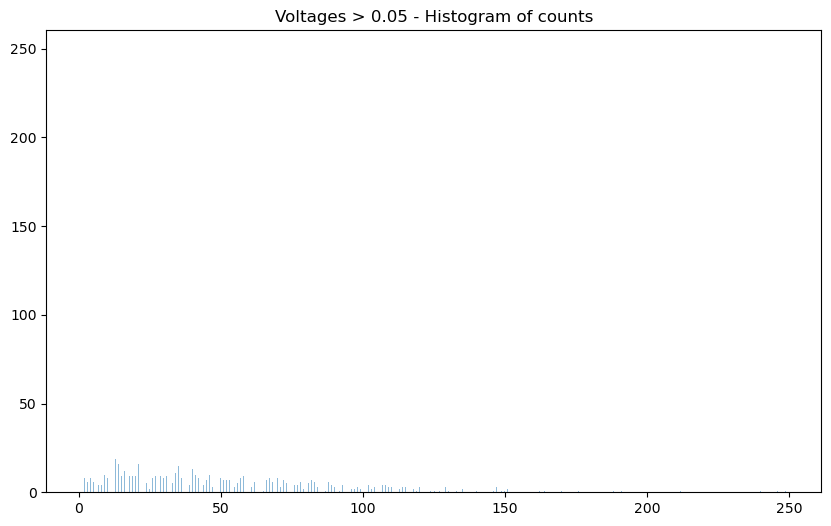

In [9]:
thr=0.05
count=np.sum(voltages_so_far>thr,axis=0)
plt.figure(figsize=(10, 6))
plt.hist(count, bins=1000, alpha=0.5)
plt.title(f'Voltages > {thr} - Histogram of counts');

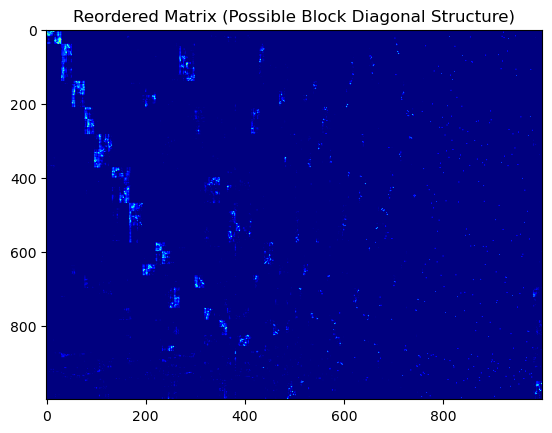

In [10]:
from scipy.cluster.hierarchy import linkage, leaves_list

mask = voltages_so_far <= 0.1
V=voltages_so_far
V[mask]=0
V.shape,mask.shape


# Compute linkage on rows and columns
row_linkage = linkage(V, method='ward')
col_linkage = linkage(V.T, method='ward')

# Get the order of rows and columns
row_order = leaves_list(row_linkage)
col_order = leaves_list(col_linkage)

# Reorder the matrix
reordered = V[row_order, :][:, col_order]

plt.imshow(reordered, aspect='auto', cmap='jet')
plt.title("Reordered Matrix (Possible Block Diagonal Structure)")
plt.show()